In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
prsa_data = pd.read_csv("./data/PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


In [85]:
prsa_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  str    
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  str    
dtypes: float64(7), int64(2), str(2)
memory usage: 2.9 MB


In [86]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


In [87]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


<Axes: xlabel='SO2', ylabel='Count'>

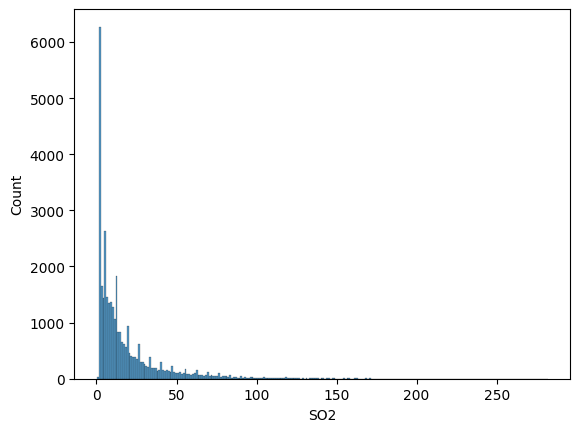

In [88]:
import seaborn as sns
sns.histplot(prsa_data.SO2)

<Axes: xlabel='NO2', ylabel='Density'>

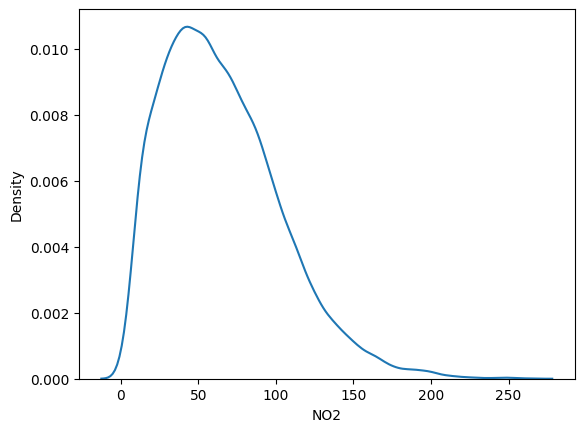

In [89]:
sns.kdeplot(prsa_data.NO2)

<Axes: xlabel='CO', ylabel='Count'>

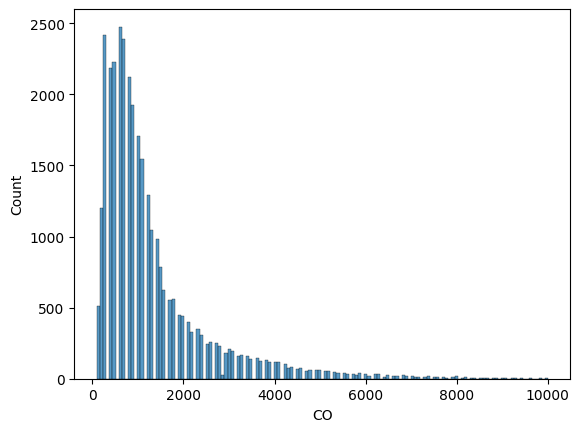

In [90]:
sns.histplot(prsa_data.CO)

<Axes: xlabel='O3', ylabel='Count'>

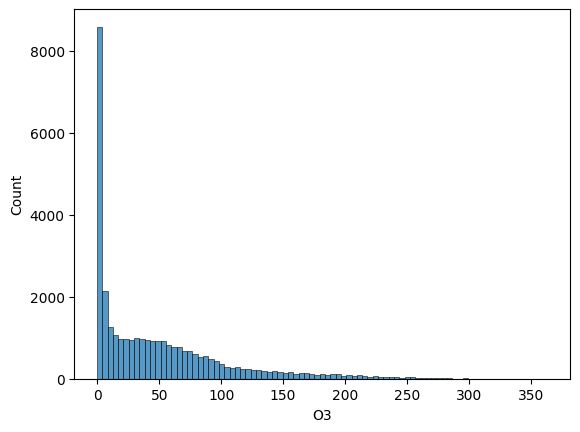

In [91]:
sns.histplot(prsa_data.O3)

<Axes: xlabel='PRES', ylabel='Count'>

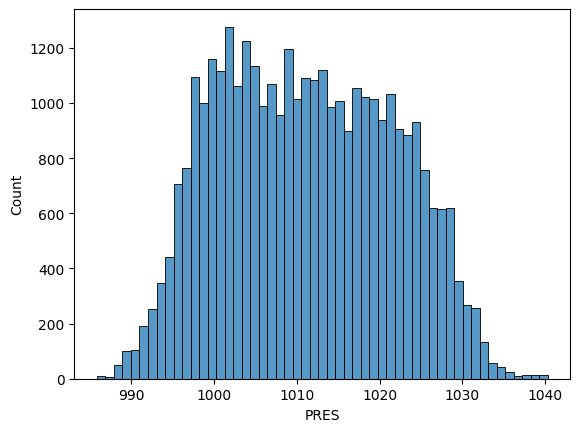

In [92]:
sns.histplot(prsa_data.PRES)

<Axes: xlabel='RAIN', ylabel='Count'>

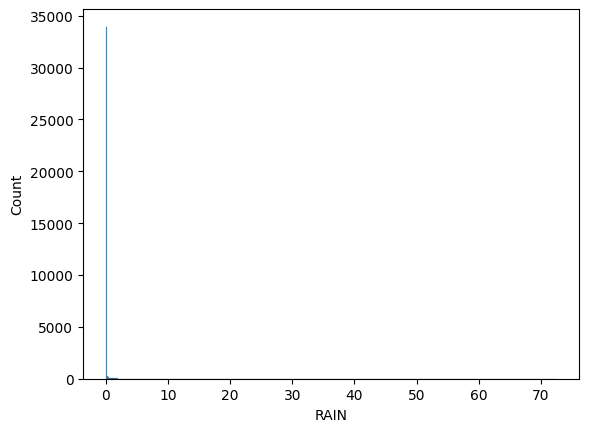

In [93]:
sns.histplot(prsa_data.RAIN)

<Axes: xlabel='WSPM', ylabel='Count'>

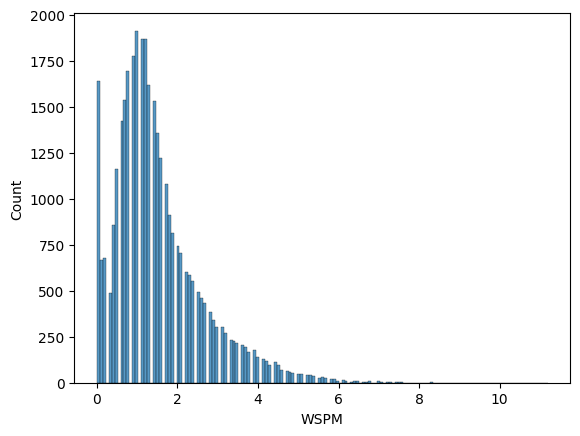

In [94]:
sns.histplot(prsa_data.WSPM)

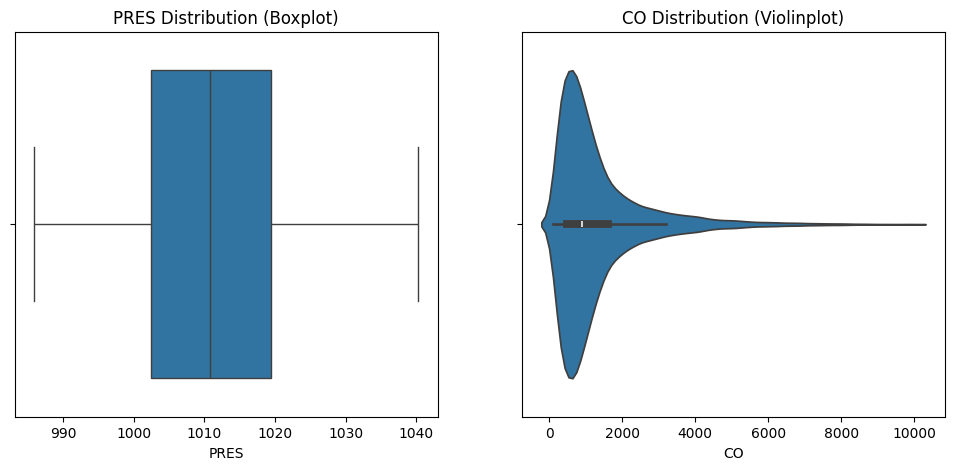

In [95]:
# 1 extra
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=prsa_data['PRES'], ax=axes[0])
axes[0].set_title('PRES Distribution (Boxplot)')
sns.violinplot(x=prsa_data['CO'], ax=axes[1])
axes[1].set_title('CO Distribution (Violinplot)')
plt.show()


In [96]:
prsa_data.RAIN[prsa_data.RAIN > 0]

267      0.1
268      0.4
269      0.1
270      0.9
271      0.9
        ... 
34891    0.2
34892    0.7
34893    0.9
34894    0.4
34895    0.2
Name: RAIN, Length: 1436, dtype: float64

In [97]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


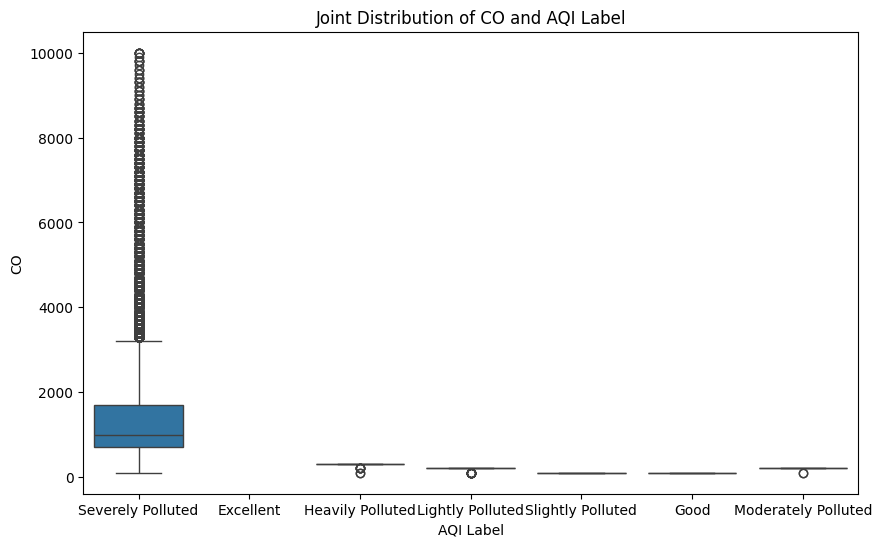

In [98]:
# 1 extra

plt.figure(figsize=(10, 6))
sns.boxplot(x="AQI Label", y="CO", data=prsa_data)
plt.title('Joint Distribution of CO and AQI Label')
#plt.yscale('log') # Useful if the data has a wide range
plt.show()

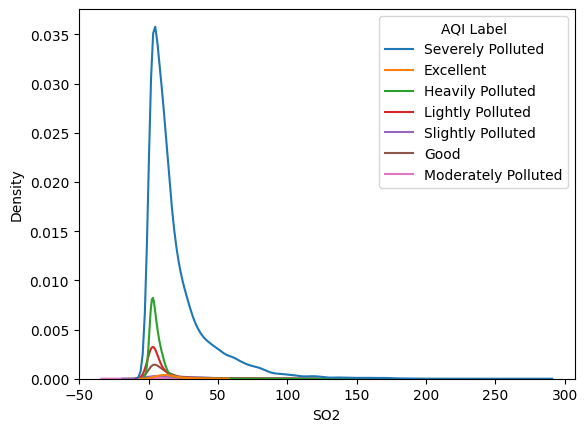

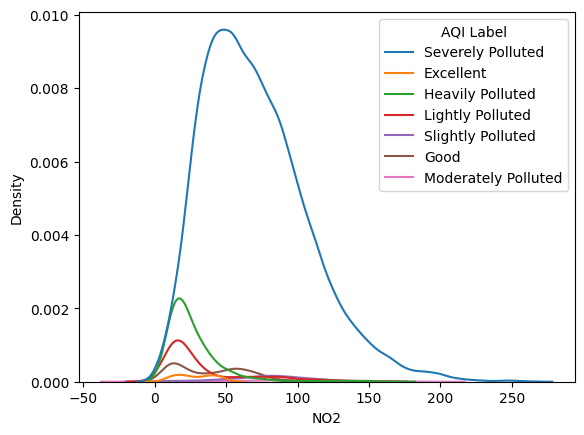

/var/folders/4d/1d5j55lj60v45fpt1wk0gwm80000gn/T/ipykernel_13497/1422201488.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


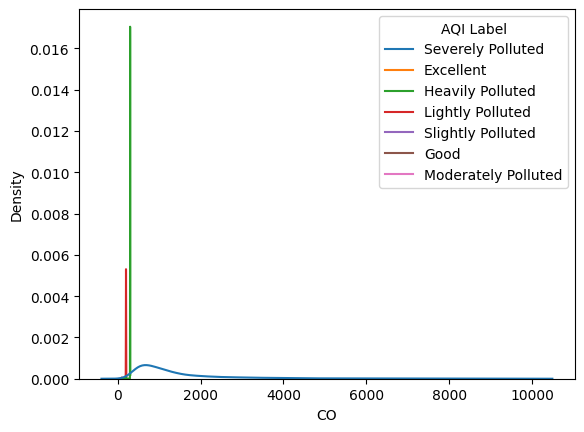

In [99]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")
plt.show()
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")
plt.show()
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")
plt.show()

/var/folders/4d/1d5j55lj60v45fpt1wk0gwm80000gn/T/ipykernel_13497/2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

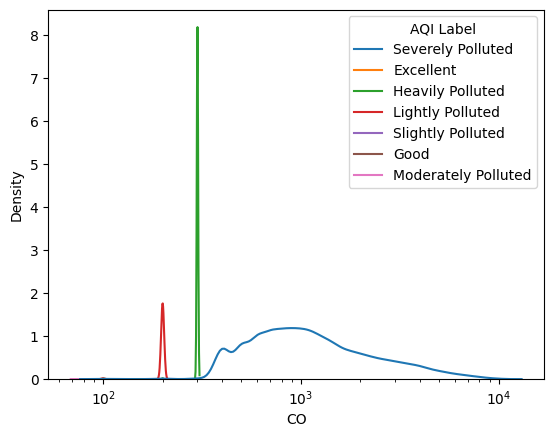

In [100]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

In [101]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']), 
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [102]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


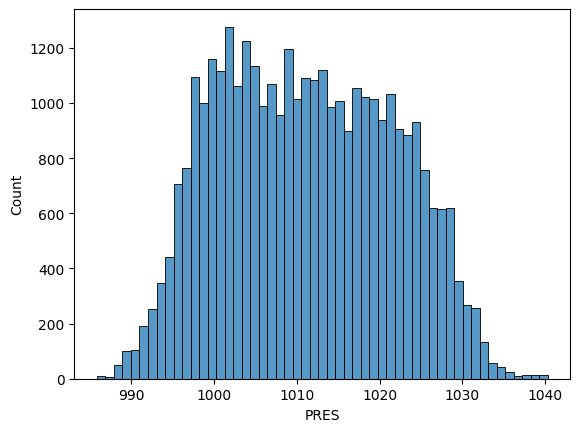

In [103]:
sns.histplot(prsa_data.PRES)
plt.show()

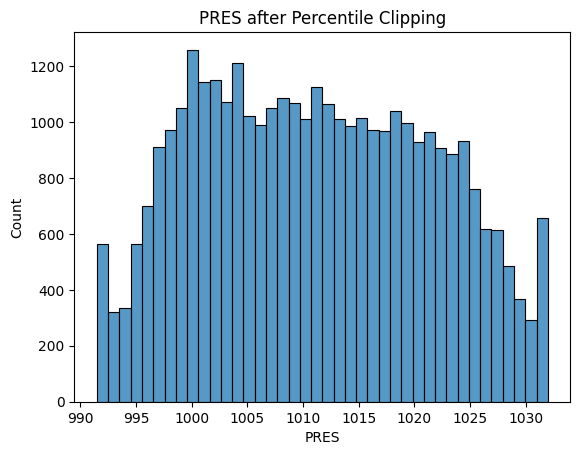

In [104]:
# extra 2
lower_bound = prsa_data["PRES"].quantile(0.01)
upper_bound = prsa_data["PRES"].quantile(0.99)

prsa_data["PRES"] = prsa_data["PRES"].clip(lower=lower_bound, upper=upper_bound)

sns.histplot(prsa_data.PRES)
plt.title("PRES after Percentile Clipping")
plt.show()

<Axes: >

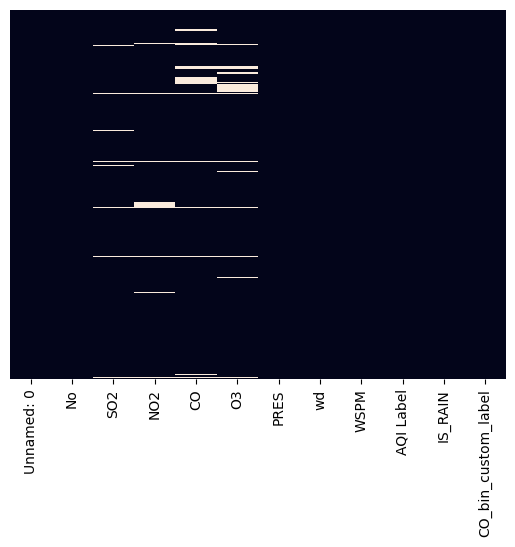

In [105]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [106]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 884, dtype: int64

<Axes: >

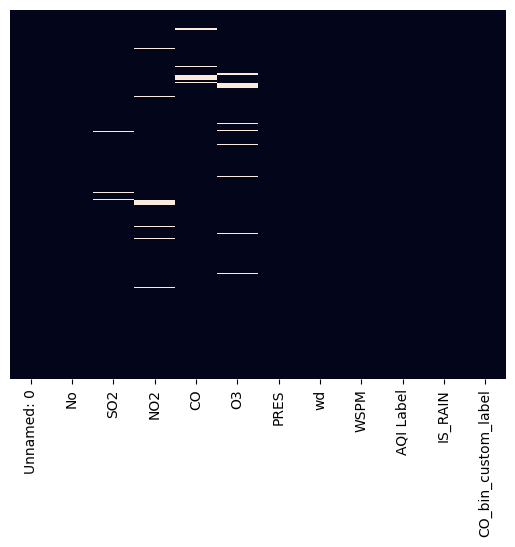

In [107]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [108]:
prsa_data.isnull().sum()

Unnamed: 0                0
No                        0
SO2                     281
NO2                     702
CO                     1028
O3                     1300
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

In [109]:
# 3 extra

from sklearn.impute import SimpleImputer

num_cols = prsa_data.select_dtypes(include=[np.number]).columns
cols_with_na = prsa_data[num_cols].columns[prsa_data[num_cols].isna().any()].tolist()

if cols_with_na:
    print(f"Imputing missing values for: {cols_with_na}")
    imputer = SimpleImputer(strategy='median')
    prsa_data[cols_with_na] = imputer.fit_transform(prsa_data[cols_with_na])

print(prsa_data.isnull().sum())

Imputing missing values for: ['SO2', 'NO2', 'CO', 'O3']
Unnamed: 0             0
No                     0
SO2                    0
NO2                    0
CO                     0
O3                     0
PRES                   0
wd                     0
WSPM                   0
AQI Label              0
IS_RAIN                0
CO_bin_custom_label    0
dtype: int64


<Axes: xlabel='SO2', ylabel='Count'>

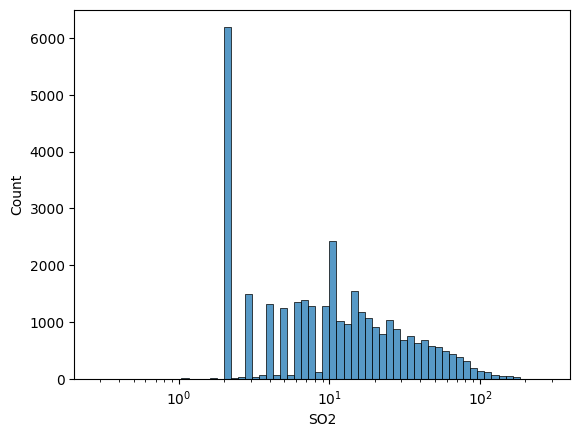

In [110]:
sns.histplot(prsa_data.SO2, log_scale=True)

In [111]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())

<Axes: xlabel='SO2', ylabel='Count'>

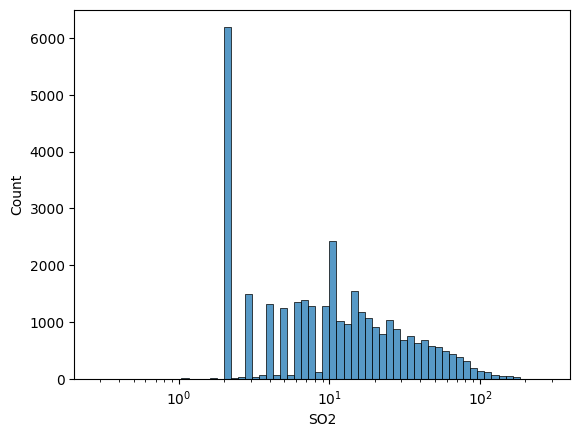

In [112]:
sns.histplot(prsa_data.SO2, log_scale=True)

In [113]:
filler = prsa_data.O3[prsa_data.O3.isna()]
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)
filler

Series([], Name: O3, dtype: float64)

<Axes: xlabel='O3', ylabel='Count'>

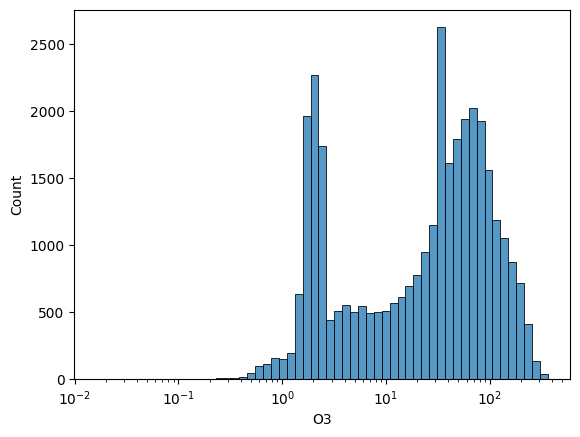

In [114]:
sns.histplot(prsa_data.O3, log_scale=True)

In [115]:
prsa_data.O3 = prsa_data.O3.fillna(filler)
filler.sum() == prsa_data.O3.sum()

np.False_

<Axes: xlabel='O3', ylabel='Count'>

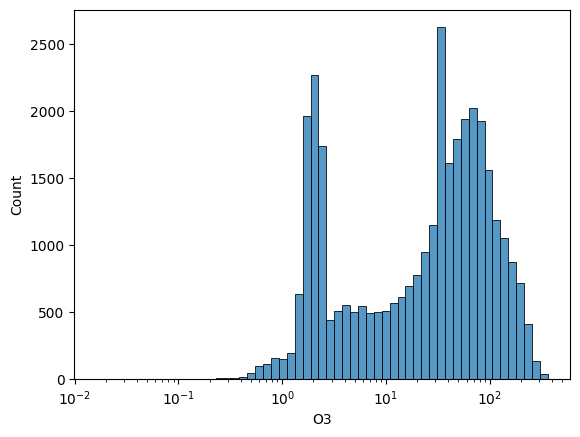

In [116]:
sns.histplot(prsa_data.O3, log_scale=True)

In [117]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,10.0,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.0,59.0,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.0,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


<Axes: xlabel='SO2', ylabel='Count'>

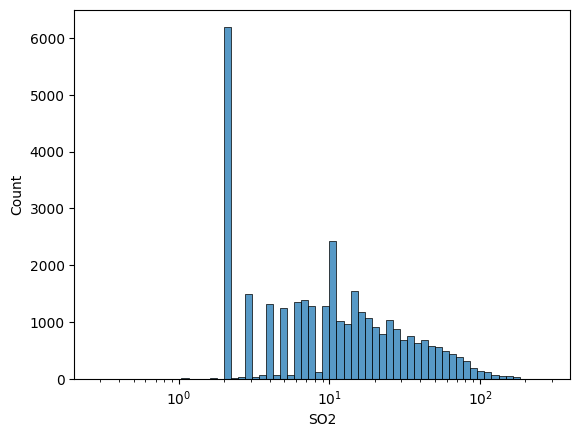

In [118]:
sns.histplot(prsa_data.SO2, log_scale=True)

In [119]:
prsa_data.SO2 = np.log(prsa_data.SO2)

<Axes: xlabel='SO2', ylabel='Count'>

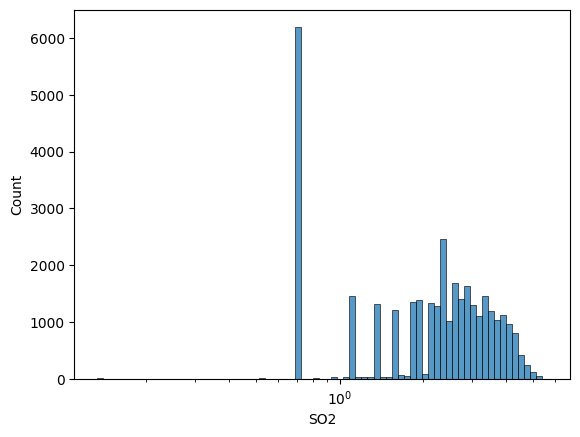

In [120]:
sns.histplot(prsa_data.SO2, log_scale=True)

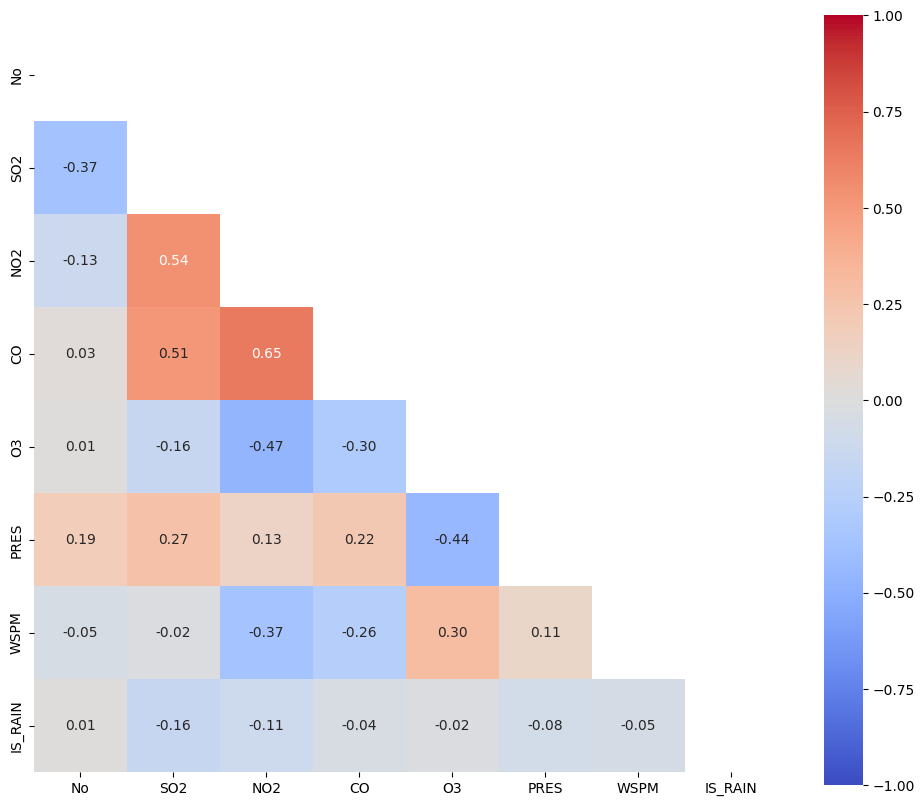

In [ ]:
# 5 extra

plt.figure(figsize=(12, 10))
prsa_data = prsa_data.drop(columns=['Unnamed: 0', 'CO_bin_custom_label'])  # useless
corr_matrix = prsa_data.corr(numeric_only=True)


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.show()


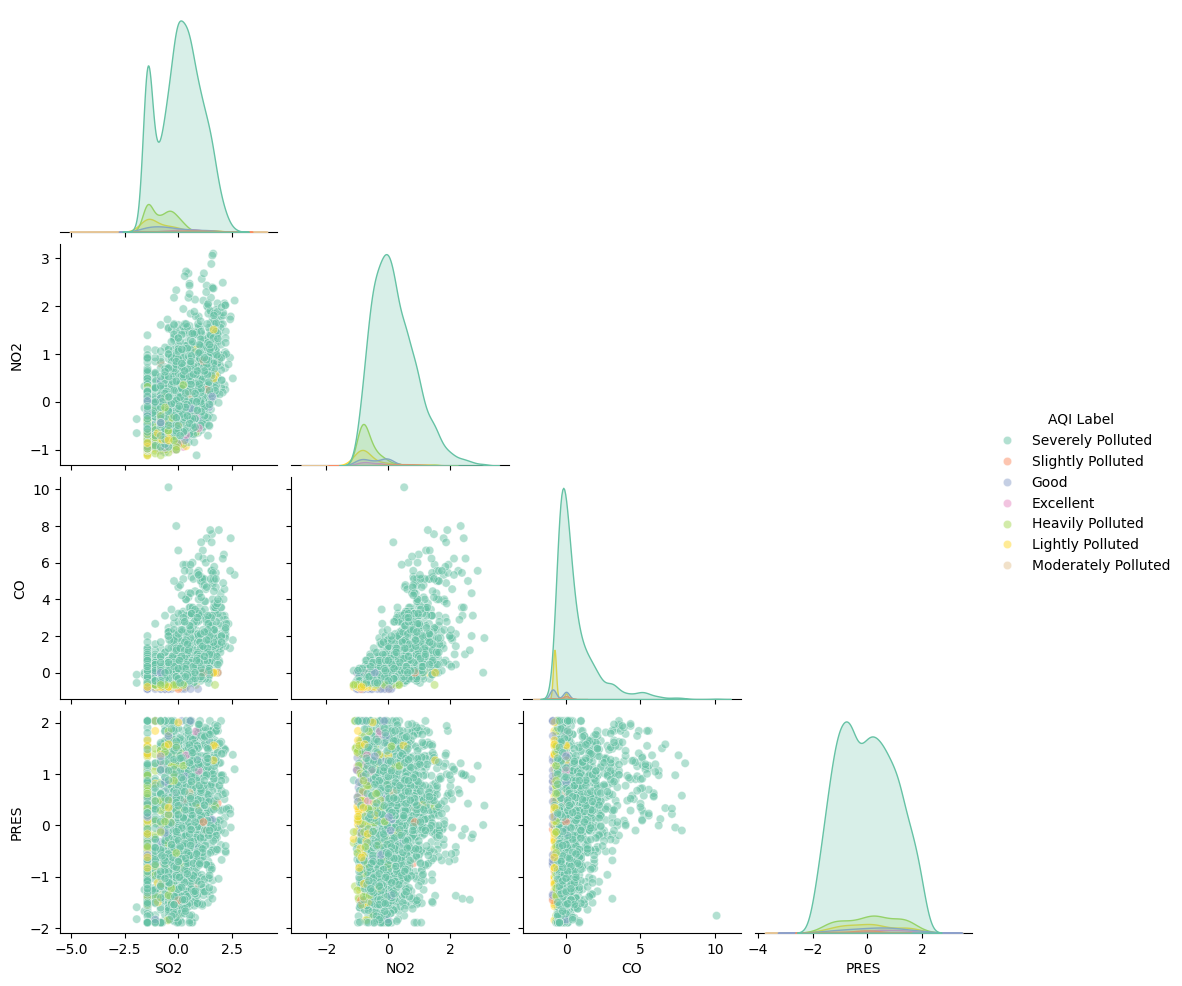

In [128]:
# 6 extra
features_to_plot = ['SO2', 'NO2', 'CO', 'PRES', 'AQI Label']

sns.pairplot(prsa_data[features_to_plot].sample(min(2000, len(prsa_data))), 
             hue='AQI Label', 
             palette='Set2', 
             diag_kind='kde', 
             corner=True,
             plot_kws={'alpha':0.5}) 

plt.show()

# also take a look at 5 for a conclusion

In [125]:
prsa_data.head()# 4 extra

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN
0,1,-0.453964,-0.607843,-0.555556,52,1.160094,NNW,2.583333,Severely Polluted,0.0
1,2,-0.453964,-0.607843,-0.555556,50,1.179490,N,2.833333,Severely Polluted,0.0
2,3,0.002212,-0.784314,-0.555556,55,1.208584,NNW,3.583333,Severely Polluted,0.0
4,5,-0.091877,0.000000,-0.666667,54,1.373451,N,0.583333,Heavily Polluted,0.0
5,6,-0.197059,-0.823529,-0.666667,54,1.412243,N,2.000000,Heavily Polluted,0.0


In [126]:
# 4 extra

from sklearn.preprocessing import RobustScaler, StandardScaler

robust_features = ['CO', 'NO2', 'WSPM']
robust_scaler = RobustScaler()
prsa_data[robust_features] = robust_scaler.fit_transform(prsa_data[robust_features])

standard_features = ['PRES', 'SO2'] # symmetric features
standard_scaler = StandardScaler()
prsa_data[standard_features] = standard_scaler.fit_transform(prsa_data[standard_features])

prsa_data.head()

,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN
0,1,-0.453964,-0.607843,-0.555556,52,1.160094,NNW,2.583333,Severely Polluted,0.0
1,2,-0.453964,-0.607843,-0.555556,50,1.179490,N,2.833333,Severely Polluted,0.0
2,3,0.002212,-0.784314,-0.555556,55,1.208584,NNW,3.583333,Severely Polluted,0.0
4,5,-0.091877,0.000000,-0.666667,54,1.373451,N,0.583333,Heavily Polluted,0.0
5,6,-0.197059,-0.823529,-0.666667,54,1.412243,N,2.000000,Heavily Polluted,0.0
